In [3]:

print("STEP 1: Initialize Spark Session (Feature Engineering)")


import os

os.environ['JAVA_TOOL_OPTIONS'] = '-Djava.net.preferIPv4Stack=true'
os.environ['SPARK_LOCAL_HOSTNAME'] = 'localhost'
os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("WildChat_FeatureEngineering") \
    .master("local[*]") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "50") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

print(" SparkSession initialized successfully")
print("Spark Version:", spark.version)

STEP 1: Initialize Spark Session (Feature Engineering)


Picked up JAVA_TOOL_OPTIONS: -Djava.net.preferIPv4Stack=true
Picked up JAVA_TOOL_OPTIONS: -Djava.net.preferIPv4Stack=true
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/28 08:51:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/28 08:51:18 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


 SparkSession initialized successfully
Spark Version: 4.1.1


In [4]:

print("Load Final Ingestion Dataset")

input_path = "wildchat_final_ingestion.parquet"

df = spark.read.parquet(input_path)

print(" Dataset Loaded Successfully")
print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))

df.printSchema()

Load Final Ingestion Dataset
 Dataset Loaded Successfully
Total Rows: 200000
Total Columns: 10
root
 |-- conversation_hash: string (nullable = true)
 |-- model: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- turn: long (nullable = true)
 |-- language: string (nullable = true)
 |-- toxic: boolean (nullable = true)
 |-- redacted: boolean (nullable = true)
 |-- country: string (nullable = true)
 |-- hashed_ip: string (nullable = true)
 |-- state: string (nullable = true)



In [5]:

print("Creating Time-Based Features")


from pyspark.sql.functions import to_date, hour, dayofweek

df = df.withColumn("date", to_date("timestamp")) \
       .withColumn("hour", hour("timestamp")) \
       .withColumn("day_of_week", dayofweek("timestamp"))

print(" Time features created")

df.select("timestamp", "date", "hour", "day_of_week").show(5, False)

Creating Time-Based Features
 Time features created
+-------------------+----------+----+-----------+
|timestamp          |date      |hour|day_of_week|
+-------------------+----------+----+-----------+
|2023-05-30 11:40:31|2023-05-30|11  |3          |
|2023-05-30 11:41:23|2023-05-30|11  |3          |
|2023-05-30 11:41:29|2023-05-30|11  |3          |
|2023-05-30 11:41:33|2023-05-30|11  |3          |
|2023-05-30 11:41:39|2023-05-30|11  |3          |
+-------------------+----------+----+-----------+
only showing top 5 rows


In [6]:

print(" Creating User Activity Feature")


user_activity = df.groupBy("hashed_ip") \
                  .count() \
                  .withColumnRenamed("count", "user_message_count")

df = df.join(user_activity, on="hashed_ip", how="left")

print(" User activity feature added")
df.select("hashed_ip", "user_message_count").show(5)


 Creating User Activity Feature
 User activity feature added
+--------------------+------------------+
|           hashed_ip|user_message_count|
+--------------------+------------------+
|2696f7abd336fb13e...|                32|
|e7a5088a0b41fac77...|                16|
|5e5b46609cb861e1a...|                 2|
|cdc1540b914067be1...|                68|
|07ea05158781d530d...|                 1|
+--------------------+------------------+
only showing top 5 rows


In [7]:

print(" Turn Statistics")


df.select("turn").describe().show()


 Turn Statistics
+-------+------------------+
|summary|              turn|
+-------+------------------+
|  count|            200000|
|   mean|           2.63235|
| stddev|2.8753877680713043|
|    min|                 1|
|    max|                59|
+-------+------------------+



In [8]:

print("STEP 7: Saving Feature Engineered Dataset")


output_path = "wildchat_feature_engineered.parquet"

df.write.mode("overwrite").parquet(output_path)

print(" Feature Engineered Dataset Saved Successfully")

STEP 7: Saving Feature Engineered Dataset


[Stage 15:>                                                       (0 + 16) / 16]

 Feature Engineered Dataset Saved Successfully


In [9]:

print("VALIDATING NEW FEATURES")

print("Total Columns:", len(df.columns))
df.printSchema()

print("Check Nulls in New Columns")

from pyspark.sql.functions import col

df.select(
    col("date").isNull().alias("date_null"),
    col("hour").isNull().alias("hour_null"),
    col("user_message_count").isNull().alias("user_msg_null")
).show(5)

VALIDATING NEW FEATURES
Total Columns: 14
root
 |-- hashed_ip: string (nullable = true)
 |-- conversation_hash: string (nullable = true)
 |-- model: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- turn: long (nullable = true)
 |-- language: string (nullable = true)
 |-- toxic: boolean (nullable = true)
 |-- redacted: boolean (nullable = true)
 |-- country: string (nullable = true)
 |-- state: string (nullable = true)
 |-- date: date (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- user_message_count: long (nullable = true)

Check Nulls in New Columns
+---------+---------+-------------+
|date_null|hour_null|user_msg_null|
+---------+---------+-------------+
|    false|    false|        false|
|    false|    false|        false|
|    false|    false|        false|
|    false|    false|        false|
|    false|    false|        false|
+---------+---------+-------------+
only showing top 5 rows


In [11]:
pip install matplotlib pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 14.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 14.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 14.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 9.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [12]:
import matplotlib.pyplot as plt
import pandas as pd

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


EDA: Messages by Hour


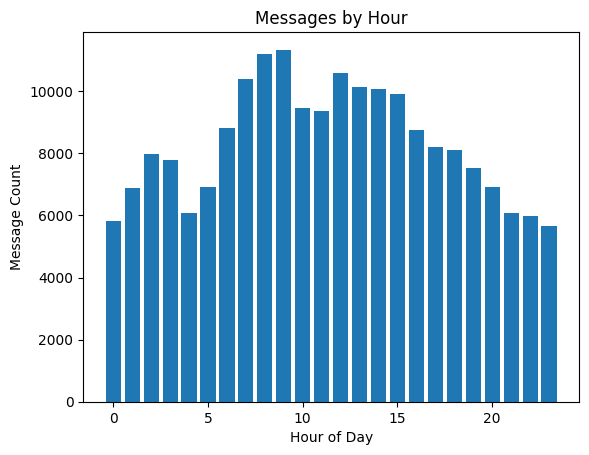

In [13]:

print("EDA: Messages by Hour")


hour_df = df.groupBy("hour") \
            .count() \
            .orderBy("hour")

hour_pd = hour_df.toPandas()

plt.figure()
plt.bar(hour_pd["hour"], hour_pd["count"])
plt.xlabel("Hour of Day")
plt.ylabel("Message Count")
plt.title("Messages by Hour")
plt.show()

EDA: Messages by Day of Week


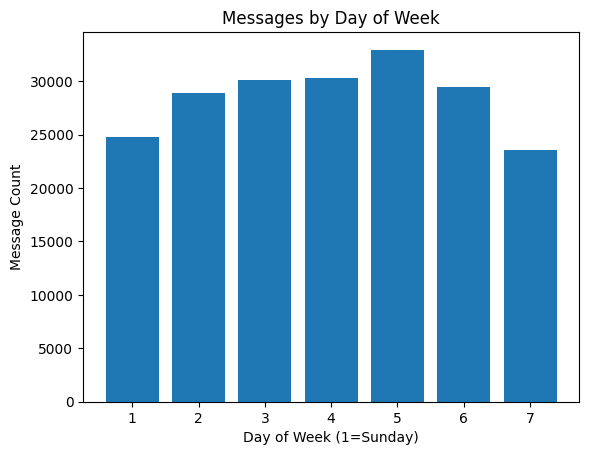

In [15]:

print("EDA: Messages by Day of Week")


day_df = df.groupBy("day_of_week") \
           .count() \
           .orderBy("day_of_week")

day_pd = day_df.toPandas()

plt.figure()
plt.bar(day_pd["day_of_week"], day_pd["count"])
plt.xlabel("Day of Week (1=Sunday)")
plt.ylabel("Message Count")
plt.title("Messages by Day of Week")
plt.show()

EDA: Top 10 Countries


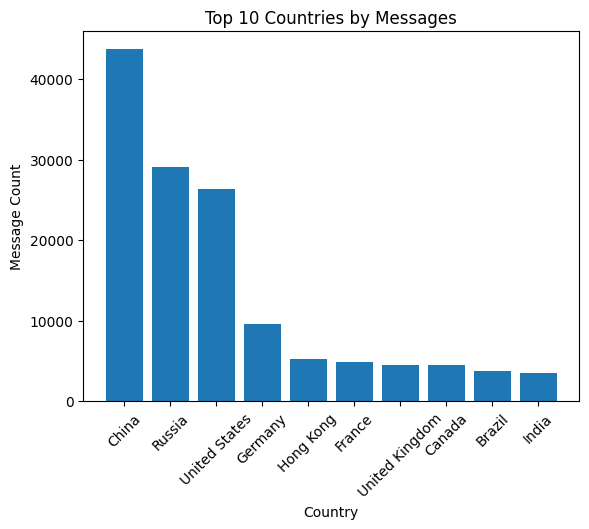

In [16]:

print("EDA: Top 10 Countries")


country_df = df.groupBy("country") \
               .count() \
               .orderBy("count", ascending=False) \
               .limit(10)

country_pd = country_df.toPandas()

plt.figure()
plt.bar(country_pd["country"], country_pd["count"])
plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Message Count")
plt.title("Top 10 Countries by Messages")
plt.show()

EDA: User Message Count Distribution


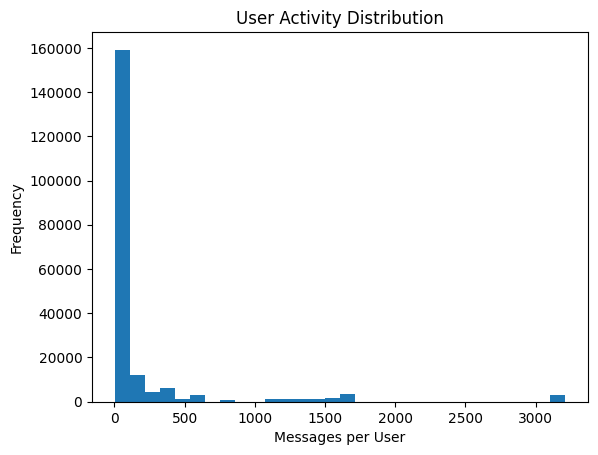

In [17]:

print("EDA: User Message Count Distribution")


user_pd = df.select("user_message_count").toPandas()

plt.figure()
plt.hist(user_pd["user_message_count"], bins=30)
plt.xlabel("Messages per User")
plt.ylabel("Frequency")
plt.title("User Activity Distribution")
plt.show()

EDA: Daily Message Trend


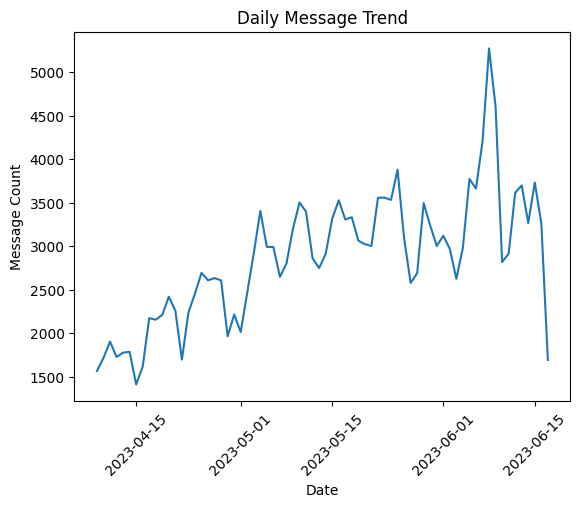

In [18]:

print("EDA: Daily Message Trend")


daily_df = df.groupBy("date") \
             .count() \
             .orderBy("date")

daily_pd = daily_df.toPandas()

plt.figure()
plt.plot(daily_pd["date"], daily_pd["count"])
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Message Count")
plt.title("Daily Message Trend")
plt.show()

In [19]:

print(" Encoding Categorical Features")


from pyspark.ml.feature import StringIndexer

categorical_cols = ["model", "language", "country", "state"]

indexers = [
    StringIndexer(inputCol=col, outputCol=col+"_index", handleInvalid="keep")
    for col in categorical_cols
]

for indexer in indexers:
    df = indexer.fit(df).transform(df)

print(" Categorical Encoding Completed")

df.select("model", "model_index",
          "language", "language_index",
          "country", "country_index",
          "state", "state_index").show(5)

 Encoding Categorical Features
 Categorical Encoding Completed
+------------------+-----------+--------+--------------+-----------+-------------+-------------------+-----------+
|             model|model_index|language|language_index|    country|country_index|              state|state_index|
+------------------+-----------+--------+--------------+-----------+-------------+-------------------+-----------+
|gpt-3.5-turbo-0301|        0.0| Russian|           2.0|     Russia|          1.0|             Moscow|        2.0|
|gpt-3.5-turbo-0301|        0.0| English|           0.0| Uzbekistan|         43.0|           Tashkent|       78.0|
|gpt-3.5-turbo-0301|        0.0| English|           0.0|       Iraq|         66.0|            Baghdad|      210.0|
|gpt-3.5-turbo-0301|        0.0| Russian|           2.0|     Russia|          1.0|   Volgograd Oblast|      127.0|
|gpt-3.5-turbo-0301|        0.0| English|           0.0|Philippines|         16.0|Province of Bulacan|      522.0|
+----------------

In [20]:
from pyspark.ml.feature import OneHotEncoder

encoder = OneHotEncoder(
    inputCols=[col+"_index" for col in categorical_cols],
    outputCols=[col+"_ohe" for col in categorical_cols]
)

df = encoder.fit(df).transform(df)

print(" One Hot Encoding Completed")

 One Hot Encoding Completed


In [22]:
print("Current Columns:")
print(df.columns)

Current Columns:
['hashed_ip', 'conversation_hash', 'model', 'timestamp', 'turn', 'language', 'toxic', 'redacted', 'country', 'state', 'date', 'hour', 'day_of_week', 'user_message_count', 'model_index', 'language_index', 'country_index', 'state_index', 'model_ohe', 'language_ohe', 'country_ohe', 'state_ohe']


In [23]:

print("Creating Conversation-Level Features")


from pyspark.sql.functions import count, max

conv_features = df.groupBy("conversation_hash") \
    .agg(
        count("*").alias("conversation_length"),
        max("turn").alias("max_turn")
    )

df = df.join(conv_features, on="conversation_hash", how="left")

print(" Conversation features added")
df.select("conversation_hash", "conversation_length", "max_turn").show(5)

Creating Conversation-Level Features
 Conversation features added
+--------------------+-------------------+--------+
|   conversation_hash|conversation_length|max_turn|
+--------------------+-------------------+--------+
|dfdb7968a34cf34f7...|                  1|       2|
|11eee1ef230c5cee4...|                  1|       3|
|c3da1c560836f060e...|                  1|       8|
|139420a3f989f9749...|                  1|       1|
|ee3bec6bc13a65695...|                  1|       5|
+--------------------+-------------------+--------+
only showing top 5 rows


In [24]:
print("Updated Columns:")
print(df.columns)

Updated Columns:
['conversation_hash', 'hashed_ip', 'model', 'timestamp', 'turn', 'language', 'toxic', 'redacted', 'country', 'state', 'date', 'hour', 'day_of_week', 'user_message_count', 'model_index', 'language_index', 'country_index', 'state_index', 'model_ohe', 'language_ohe', 'country_ohe', 'state_ohe', 'conversation_length', 'max_turn']


In [25]:
from pyspark.ml.feature import VectorAssembler

feature_cols = [
    "conversation_length",
    "user_message_count",
    "hour",
    "day_of_week",
    "max_turn",
    "model_ohe",
    "language_ohe",
    "country_ohe",
    "state_ohe"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

df = assembler.transform(df)

print(" Feature Vector Created Successfully")
df.select("features").show(5, False)

 Feature Vector Created Successfully
+----------------------------------------------------------------------+
|features                                                              |
+----------------------------------------------------------------------+
|(1974,[0,1,2,3,4,5,9,77,254],[1.0,32.0,11.0,3.0,2.0,1.0,1.0,1.0,1.0]) |
|(1974,[0,1,2,3,4,5,7,119,330],[1.0,16.0,11.0,3.0,3.0,1.0,1.0,1.0,1.0])|
|(1974,[0,1,2,3,4,5,7,142,462],[1.0,2.0,11.0,3.0,8.0,1.0,1.0,1.0,1.0]) |
|(1974,[0,1,2,3,4,5,9,77,379],[1.0,68.0,11.0,3.0,1.0,1.0,1.0,1.0,1.0]) |
|(1974,[0,1,2,3,4,5,7,92,774],[1.0,1.0,11.0,3.0,5.0,1.0,1.0,1.0,1.0])  |
+----------------------------------------------------------------------+
only showing top 5 rows


In [26]:

print("Applying Feature Scaling")


from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="features_scaled",
    withStd=True,
    withMean=False
)

scaler_model = scaler.fit(df)
df = scaler_model.transform(df)

print(" Feature Scaling Completed")
df.select("features_scaled").show(5, False)

Applying Feature Scaling
 Feature Scaling Completed
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features_scaled                                                                                                                                                                                              |
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|(1974,[0,1,2,3,4,5,9,77,254],[0.11801631371457079,0.0632101924773894,1.7383192090952335,1.568826982050597,0.6955583598874111,2.3889339801497838,3.0562888327665623,2.8357911306169115,5.801999326237306])    |
|(1974,[0,1,2,3,4,5,7,119,330],[0.11801631371457079,0.0316050962386947,1.7383192090952335,1.568826982050597,1.043337

In [27]:
cols_to_drop = [
    "model", "language", "country", "state",
    "model_index", "language_index", "country_index", "state_index"
]

df = df.drop(*cols_to_drop)

print("Cleaned columns for modeling:")
print(df.columns)

Cleaned columns for modeling:
['conversation_hash', 'hashed_ip', 'timestamp', 'turn', 'toxic', 'redacted', 'date', 'hour', 'day_of_week', 'user_message_count', 'model_ohe', 'language_ohe', 'country_ohe', 'state_ohe', 'conversation_length', 'max_turn', 'features', 'features_scaled']


In [28]:
df = df.persist()

In [29]:

print("Persisting Feature Engineered Dataset")


from pyspark import StorageLevel

df = df.persist(StorageLevel.MEMORY_AND_DISK)

print(" DataFrame Persisted Successfully")
print("Storage Level:", df.storageLevel)
print("Total Partitions:", df.rdd.getNumPartitions())


Persisting Feature Engineered Dataset
 DataFrame Persisted Successfully
Storage Level: Disk Memory Deserialized 1x Replicated


26/02/28 09:08:05 WARN CacheManager: Asked to cache already cached data.
[Stage 117:>                                                      (0 + 16) / 16]

Total Partitions: 16


[Stage 117:================================================>      (14 + 2) / 16]

In [30]:
print("Triggering Cache Materialization...")
row_count = df.count()
print("Total Rows Cached:", row_count)
print(" Cache Fully Materialized")

Triggering Cache Materialization...
Total Rows Cached: 200000
 Cache Fully Materialized


In [31]:

print("STEP: Saving Final Feature Engineered Dataset")


output_path = "wildchat_feature_engineered_final.parquet"

df.write \
    .mode("overwrite") \
    .option("compression", "snappy") \
    .parquet(output_path)

print(" Feature Engineered Dataset Saved Successfully")
print("Path:", output_path)
print("Total Rows Saved:", df.count())


STEP: Saving Final Feature Engineered Dataset


[Stage 121:>                                                      (0 + 16) / 16]

 Feature Engineered Dataset Saved Successfully
Path: wildchat_feature_engineered_final.parquet
Total Rows Saved: 200000


In [32]:
print("="*60)
print("Spark UI URL")
print("="*60)

print(spark.sparkContext.uiWebUrl)

Spark UI URL
http://127.0.0.1:4041
